In [1]:
import pandas as pd  
import sqlite3
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [3]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

Let's find out if users have different patterns on different weekdays and at different times.

In [5]:
query= """
SELECT uid, timestamp 
FROM checker 
WHERE uid LIKE 'user_%'
"""

df = pd.read_sql(query, con)

In [6]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['weekday'] = df['timestamp'].dt.day_name()
df['hour'] = df['timestamp'].dt.strftime('%H')

In [7]:
weekday_pivot = df.pivot_table(index='weekday', columns='uid', aggfunc='size', fill_value=0)
hour_pivot = df.pivot_table(index='hour', columns='uid', aggfunc='size', fill_value=0)

In [12]:
weekdays_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_pivot = weekday_pivot.reindex(weekdays_order)

hours_order = [f'{i:02d}' for i in range(24)]
hour_pivot = hour_pivot.reindex([f'{i:02d}' for i in range(24)]).fillna(0)

In [13]:
total_commits = df['uid'].value_counts().index  # descending order
weekday_pivot = weekday_pivot[total_commits]
hour_pivot = hour_pivot[total_commits]

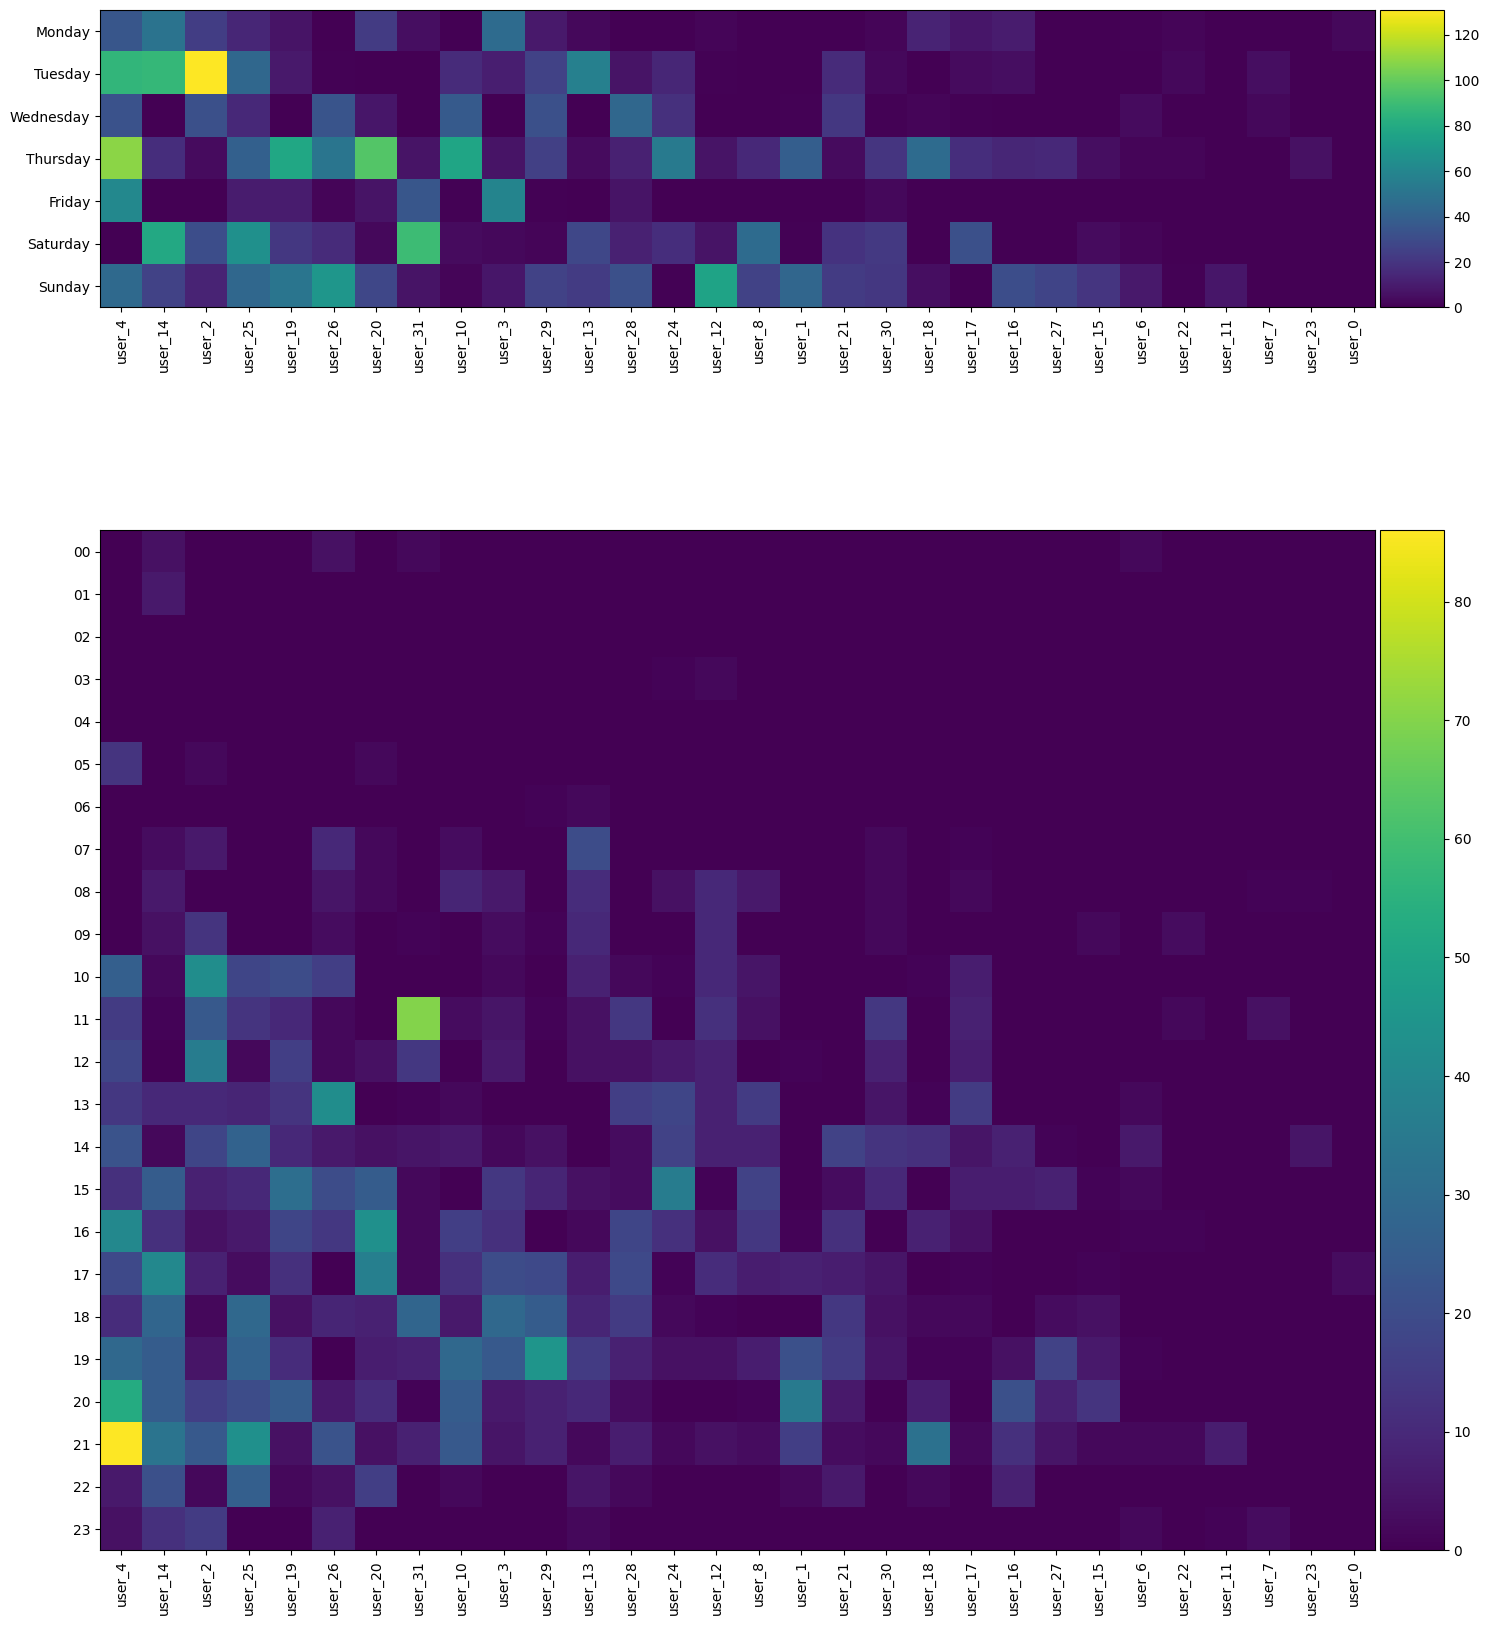

In [27]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15,20))

# Weekday heatmap
im1 = ax1.imshow(weekday_pivot.values, aspect='equal', cmap='viridis')
ax1.set_xticks(range(len(weekday_pivot.columns)))
ax1.set_xticklabels(weekday_pivot.columns, rotation=90)
ax1.set_yticks(range(len(weekday_pivot.index)))
ax1.set_yticklabels(weekday_pivot.index)

# Hour heatmap
im2 = ax2.imshow(hour_pivot.values, aspect='equal', cmap='viridis')
ax2.set_xticks(range(len(hour_pivot.columns)))
ax2.set_xticklabels(hour_pivot.columns, rotation=90)
ax2.set_yticks(range(len(hour_pivot.index)))
ax2.set_yticklabels(hour_pivot.index)

# Add colorbars
from mpl_toolkits.axes_grid1 import make_axes_locatable
for ax, im in [(ax1, im1), (ax2, im2)]:
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im, cax=cax)

plt.tight_layout()
plt.show()

- "Which user has the most commits on Tuesday?" 
-- The answer is user_2.

- "Which user has the most commits on Thursday?"
-- The answer is user_4.

- "On which weekday do users not like to make a lot of commits?"
-- Friday.


- Which user made the largest number of commits at which hour?
-- user_4 at 21.

In [28]:
conn.close()